# Aufgabe 1

Bei Aufgabe 1 war es die Aufgabe die Entladung eines Kondensators im RC Kreis für 5 verschiedene Widerstände zu messen. Die Schaltung sah wie folgt aus:
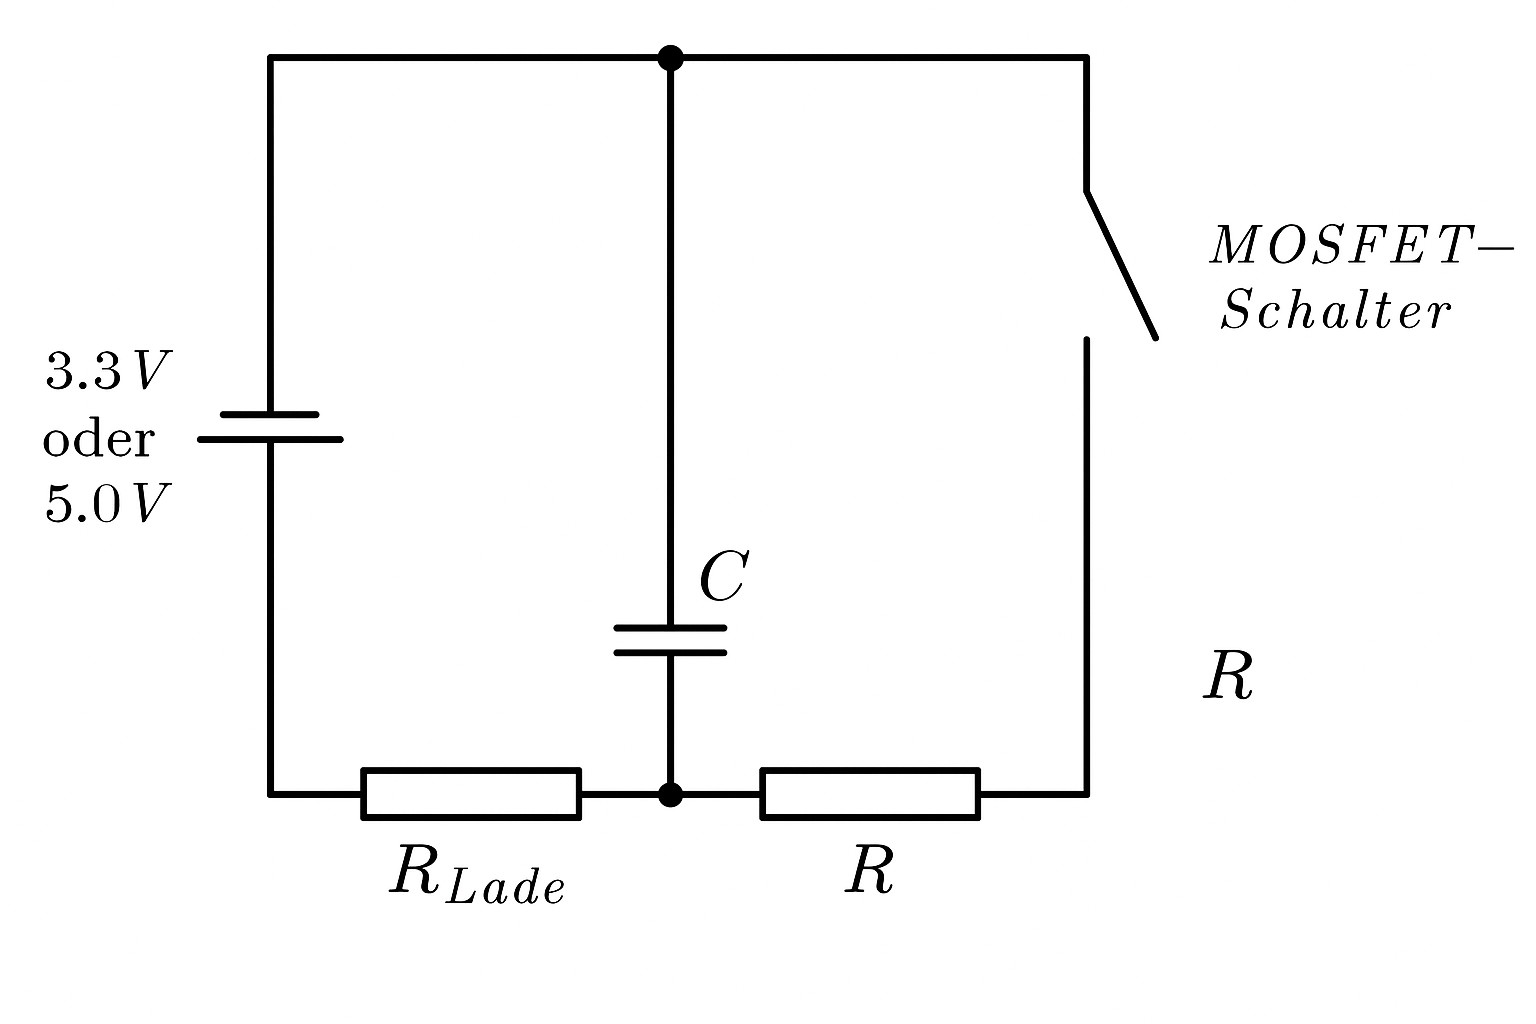

Der Widerstand $R_{lade}$ blieb dafür die ganze Zeit gleich und R wurde ausgetauscht. Genutzt haben wir dafür $R_{lade} = 986 \Omega$ und für $R$:

|Messung |R[$\Omega$]|
| ------------------------------------------- | --------------------------------------- |
| 1                            | 1,3                            | 
| 2                            | 10                              | 
| 3                           | 99,2                              | 
| 4                           | 217,3                               | 
| 5                            | 989                              | 

: Die benutzten Wiederstände bei den Versuchen und bei welchen Versuchen diese benutzt wurden

Für den Kondensator haben wir eine Kapazität von 229,9 nF gemessen. Der Arduino hat in der Schaltung in den gleichen Zeitabständen immer wieder den MOSFET-Schalter geschaltet und das Picoscope hat die Spannung über den Kondensator gemessen. Durch die immer gleichen Zeitabstände konnte das Programm "Picoscope 7" die Kurve mit richtig gewähltem Trigger gut anzeigen und die Werte dann exportiert werden.

## Messung RC-Kreis

Als erstes betrachten wir die Messungen unserer Entladung. Im folgenden sind für alle 5 Widerstände die Messwerte grafisch dargestellt. Da am Anfang noch länger das Spannungsmaximum $U_{Max}$ vorliegt und auch am Ende der Kondensator länger entladen ist, haben wir die wichtigen Daten ausgeschnitten und nur diese dargestellt um einen genaueren Verlauf der Entladung darzustellen.

C:\Users\vd01p\AppData\Local\Temp\ipykernel_5244\3495043119.py:10: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


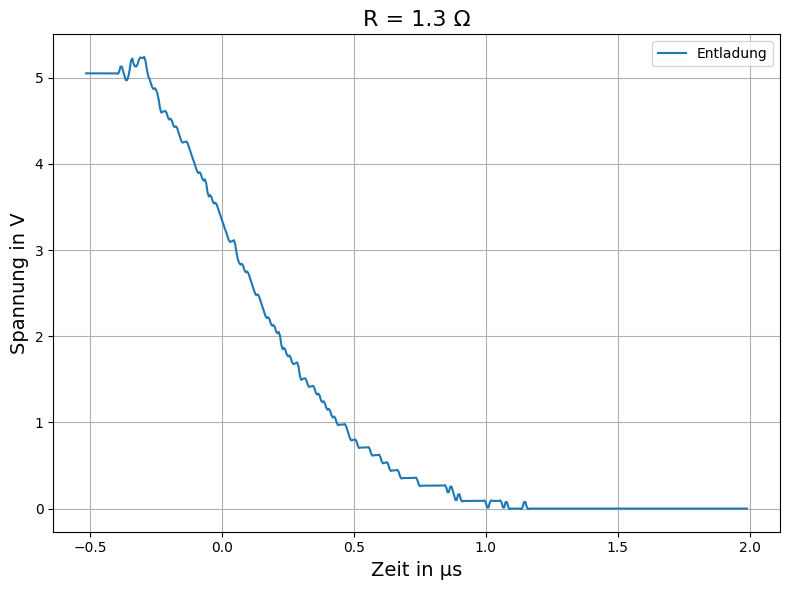

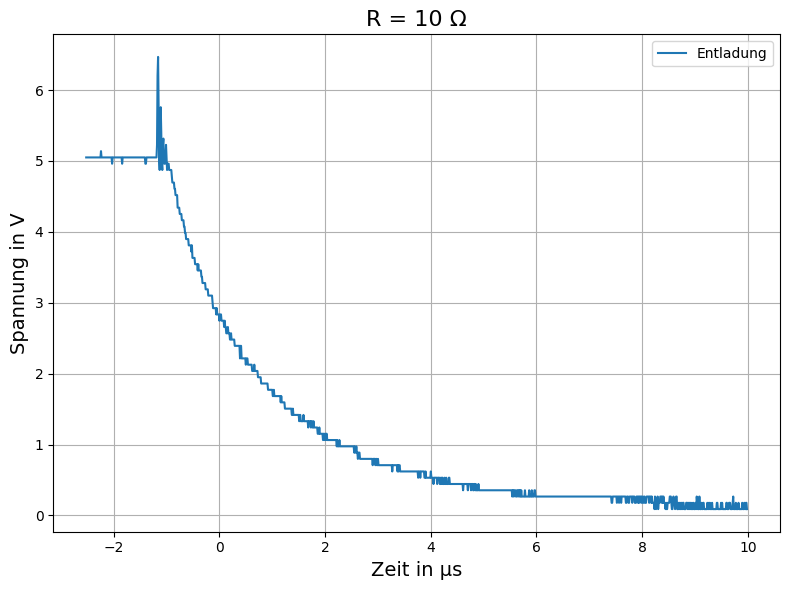

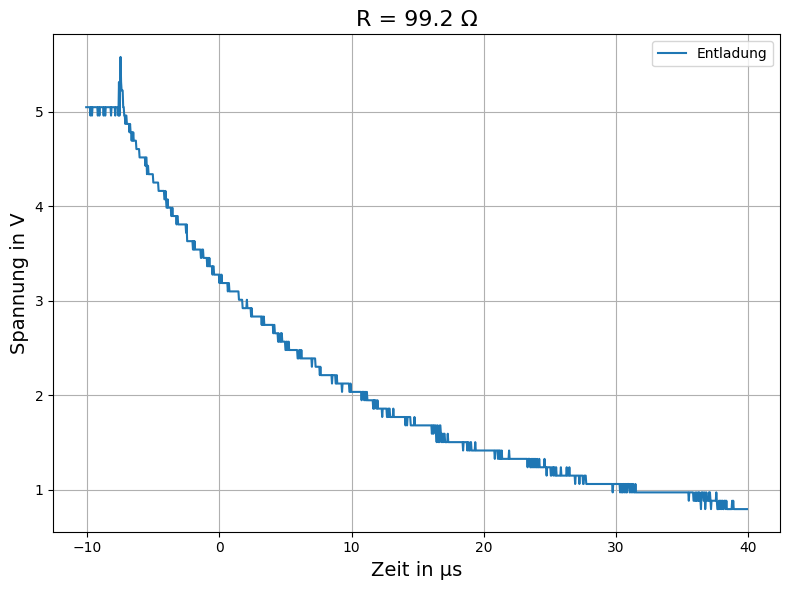

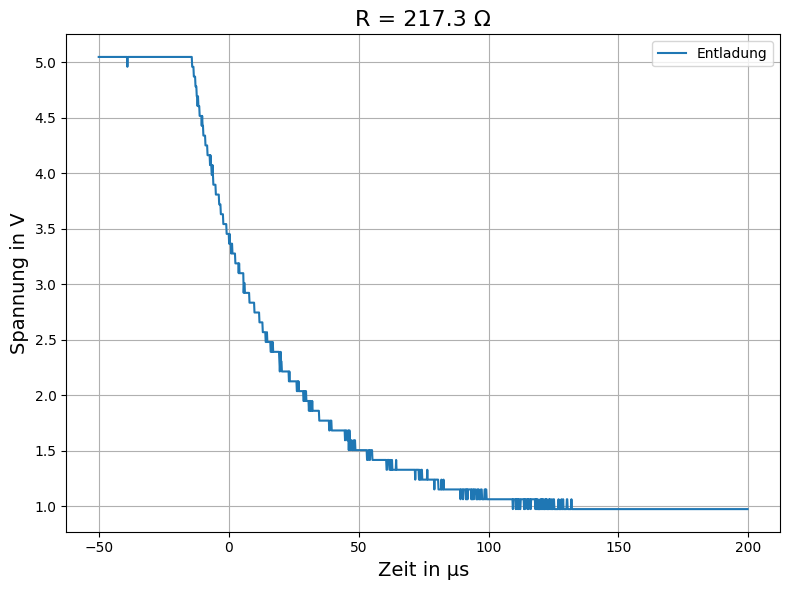

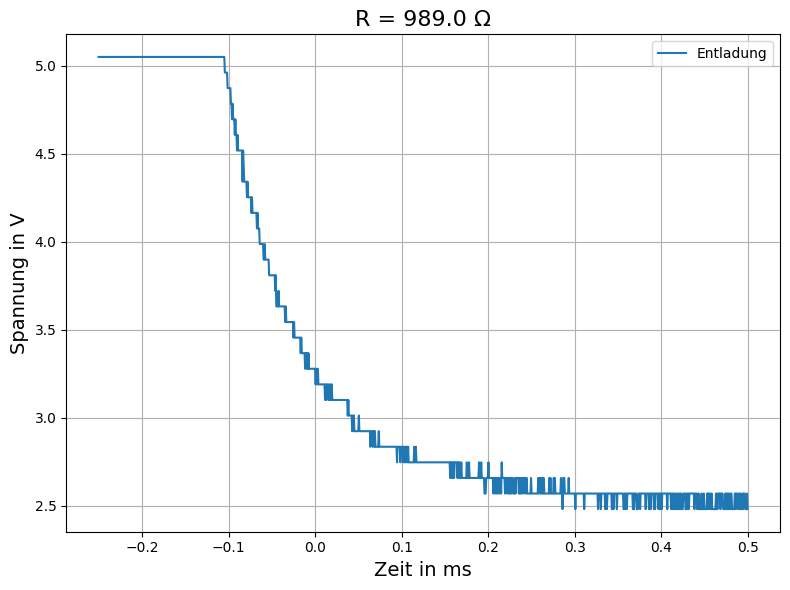

In [2]:
# | fig-cap:
# |     - Gemessene Spannung mit Wiederstand R = 1.3 Ohm
# |     - Gemessene Spannung mit Wiederstand R = 10 Ohm
# |     - Gemessene Spannung mit Wiederstand R = 99.2 Ohm
# |     - Gemessene Spannung mit Wiederstand R = 217.3 Ohm
# |     - Gemessene Spannung mit Wiederstand R = 989.0 Ohm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Resistors = [1.3, 10, 99.2, 217.3, 989.0]  # in Ohms

df_R1 = pd.read_csv('Messwerte/Aufgabe1_1R.csv')
df_R10 = pd.read_csv('Messwerte/Aufgabe1_10R.csv')
df_R100 = pd.read_csv('Messwerte/Aufgabe1_100R.csv')
df_R220 = pd.read_csv('Messwerte/Aufgabe1_220R.csv')
df_R1000 = pd.read_csv('Messwerte/Aufgabe1_1000R.csv')

dataframes = [df_R1, df_R10, df_R100, df_R220, df_R1000]
for i in range(4):
    R = Resistors[i]
    df = dataframes[i]
    n = len(df)
    start_idx = int(n * 0.45)
    end_idx   = int(n * 0.7)
    df_mid = df.iloc[start_idx:end_idx]
    plt.figure(figsize=(8, 6))
    plt.title(f'R = {R} Ω', fontsize=16)
    plt.xlabel('Zeit in µs', fontsize=14)
    plt.ylabel('Spannung in V', fontsize=14)
    plt.grid(True)
    plt.plot(df_mid['Time'], df_mid['Channel A'], label='Entladung')
    plt.legend()
    plt.tight_layout()
    plt.show()




df = dataframes[4]
R = Resistors[4]
n = len(df)
start_idx = int(n * 0.45)
end_idx   = int(n * 0.6)
df_mid = df.iloc[start_idx:end_idx]
plt.figure(figsize=(8, 6))
plt.title(f'R = {R} Ω', fontsize=16)
plt.xlabel('Zeit in ms', fontsize=14)
plt.ylabel('Spannung in V', fontsize=14)
plt.grid(True)
plt.plot(df_mid['Time'], df_mid['Channel A'], label='Entladung')
plt.legend()
plt.tight_layout()
plt.show()


# Berechnung der Impendanz und Phasenverschiebung

Berechnung von Impedanz und Phasenverschiebung eines RC-Serienkreises

Um die Impedanz $Z$ und die Phasenverschiebung $\varphi$ eines RC-Serienkreises zu bestimmen, benötigt man zwei Schritte:

## Bestimmung der Zeitkonstante aus der Entladekurve

Wird ein Kondensator über einen Widerstand entladen, folgt die Spannung einer Exponentialfunktion:

$$U_C(t) = U_0 \cdot e^{-t/\tau}$$

Mit der Zeitkonstante

$$\tau = R \cdot C$$

Aus der gemessenen Entladekurve kann man $\tau$ durch eine Exponentialanpassung oder durch Logarithmieren bestimmen.
Da der Entladewiderstand $R$ bekannt ist, ergibt sich die Kapazität des Kondensators zu:

$$C = \frac{\tau}{R}$$

Diese Kapazität ist die Grundlage für die spätere Impedanzberechnung.

## Berechnung der Impedanz im Frequenzbereich

Für eine sinusförmige Anregung mit Kreisfrequenz $\omega = 2\pi f$ besitzt ein Kondensator die komplexe Impedanz

$$Z_C = \frac{1}{j\omega C} = -j\cdot \frac{1}{\omega C}$$

Ein Serien-RC-Kreis hat daher die Gesamtimpedanz

$$Z = R - j\cdot\frac{1}{\omega C}$$

Der Betrag der Impedanz lautet:

$$|Z| = \sqrt{R^2 + \left(\frac{1}{\omega C}\right)^2}$$

Die Phasenverschiebung zwischen Strom und Spannung ergibt sich aus dem Argument der komplexen Impedanz:

$$\varphi = -\arctan \left(\frac{1}{\omega R C}\right)$$

Das Minuszeichen zeigt, dass die Spannung am RC-Glied gegenüber dem Strom nacheilt (stromführend). Da wir die Kapazität von unserem Kondensator und die Werte aller Widerstände kennen, könnten wir $\tau$ auch theoretisch berechnen. Somit können wir vergleichen wie gut unsere quantitative Berechnung anhand der Daten funktioniert hat.

Im folgenden werde ich jetzt mithilfe eines Python-Scripts $\tau$ aus meiner Messung Approximieren und damit auch $C$ und die Impendanz und Phasenverschiebung. Gleichzeitig kennen wir aber $C$ und kann somit die Impendanz und Phasenverschiebung berechnen und können dann vergleichen wie die Werte passen. Die beiden Werte werde ich dann mit einem Grafen für die Visualisierung ausgeben und die Abweichung dazu schreiben.

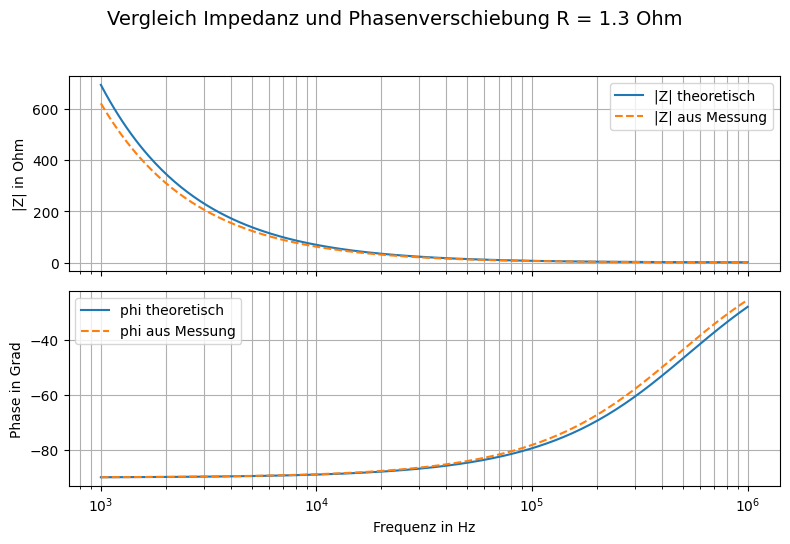

R = 1.3 Ohm
  tau_exp  = 3.336e-07 s
  C_exp    = 2.566e-07 F
  |Z|(f0)  theo = 68.709 Ohm,  Mess = 61.564 Ohm,  Abw = -10.40 %
  phi(f0)  theo = -88.92 Grad, Mess = -88.79 Grad, Abw_rel = -0.14 %



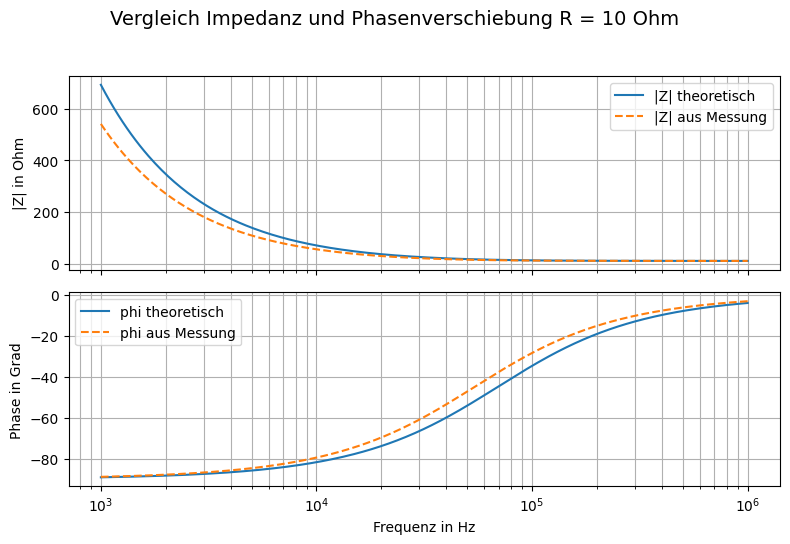

R = 10 Ohm
  tau_exp  = 2.943e-06 s
  C_exp    = 2.943e-07 F
  |Z|(f0)  theo = 69.421 Ohm,  Mess = 54.584 Ohm,  Abw = -21.37 %
  phi(f0)  theo = -81.72 Grad, Mess = -79.44 Grad, Abw_rel = -2.78 %



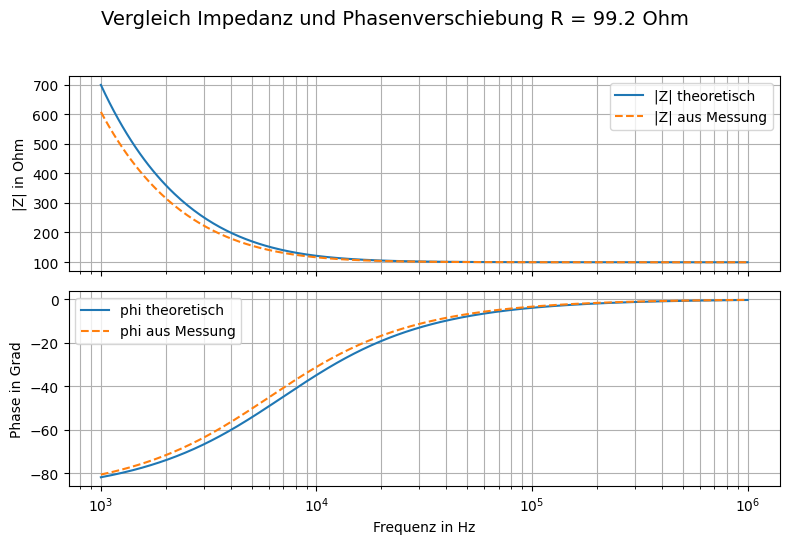

R = 99.2 Ohm
  tau_exp  = 2.632e-05 s
  C_exp    = 2.653e-07 F
  |Z|(f0)  theo = 120.664 Ohm,  Mess = 115.688 Ohm,  Abw = -4.12 %
  phi(f0)  theo = -34.70 Grad, Mess = -30.97 Grad, Abw_rel = -10.77 %



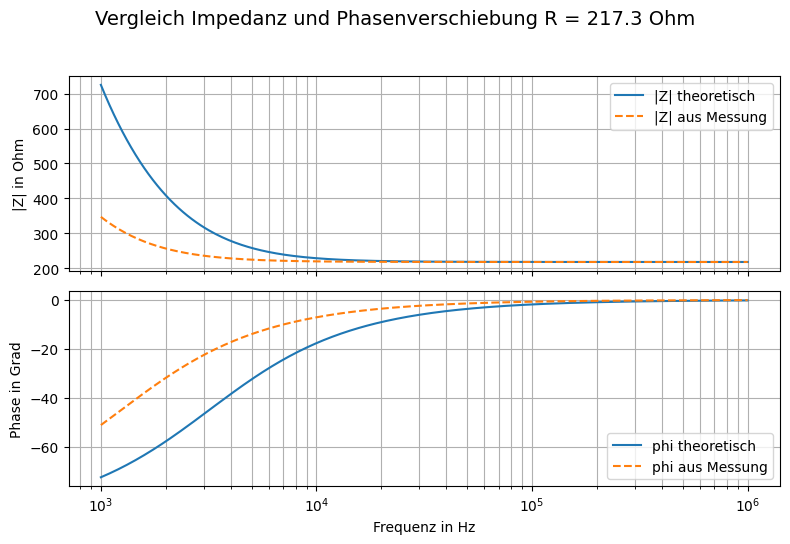

R = 217.3 Ohm
  tau_exp  = 1.279e-04 s
  C_exp    = 5.887e-07 F
  |Z|(f0)  theo = 227.900 Ohm,  Mess = 218.950 Ohm,  Abw = -3.93 %
  phi(f0)  theo = -17.54 Grad, Mess = -7.04 Grad, Abw_rel = -59.88 %



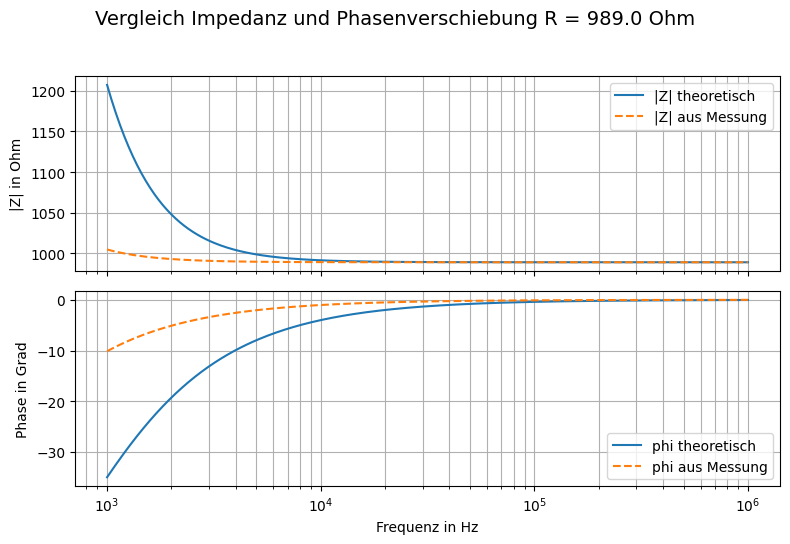

R = 989.0 Ohm
  tau_exp  = 8.896e-04 s
  C_exp    = 8.995e-07 F
  |Z|(f0)  theo = 991.383 Ohm,  Mess = 989.156 Ohm,  Abw = -0.22 %
  phi(f0)  theo = -3.97 Grad, Mess = -1.02 Grad, Abw_rel = -74.40 %



In [3]:
# | fig-cap:
# |     - Vergleich Impedanz und Phasenverschiebung R = 1.3 Ohm
# |     - Vergleich Impedanz und Phasenverschiebung R = 10 Ohm
# |     - Vergleich Impedanz und Phasenverschiebung R = 99.2 Ohm
# |     - Vergleich Impedanz und Phasenverschiebung R = 217.3 Ohm
# |     - Vergleich Impedanz und Phasenverschiebung R = 989.0 Ohm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Entladewiderstände in Ohm
Resistors = [1.3, 10, 99.2, 217.3, 989.0]

# Theoretischer Kondensatorwert
C_theo = 229.9e-9  # 229,9 nF

# Dateien einlesen
df_R1    = pd.read_csv('Messwerte/Aufgabe1_1R.csv')
df_R10   = pd.read_csv('Messwerte/Aufgabe1_10R.csv')
df_R100  = pd.read_csv('Messwerte/Aufgabe1_100R.csv')
df_R220  = pd.read_csv('Messwerte/Aufgabe1_220R.csv')
df_R1000 = pd.read_csv('Messwerte/Aufgabe1_1000R.csv')

dataframes = [df_R1, df_R10, df_R100, df_R220, df_R1000]

# Ausschnittsbereiche wie bei dir
windows = [
    (0.45, 0.70),  # R = 1.3 Ohm
    (0.45, 0.70),  # R = 10 Ohm
    (0.45, 0.70),  # R = 99.2 Ohm
    (0.45, 0.70),  # R = 217.3 Ohm
    (0.45, 0.60)   # R = 989 Ohm
]

# Zeiteinheiten: erste vier Dateien in µs, letzte in ms (falls anders bitte anpassen)
time_scales = [1e-6, 1e-6, 1e-6, 1e-6, 1e-3]

def fit_tau(time_s, voltage):
    """Bestimmt tau und U0 aus U(t) = U0 * exp(-t/tau)."""
    t = np.asarray(time_s) - time_s.iloc[0]
    v = np.asarray(voltage)

    mask = v > 0
    t = t[mask]
    v = v[mask]

    ln_v = np.log(v)
    a, b = np.polyfit(t, ln_v, 1)  # ln v = a*t + b

    tau = -1.0 / a
    U0 = np.exp(b)
    return tau, U0

def impedance_RC_series(R, C, f):
    """Komplexe Impedanz Z eines Serien-RC-Kreises bei Frequenz f (Hz)."""
    omega = 2 * np.pi * f
    return R - 1j / (omega * C)

# Frequenzachse fuer die Bode-Plots
frequencies = np.logspace(3, 6, 300)  # 1 kHz ... 1 MHz
f0 = 1e4                               # Referenzfrequenz fuer numerische Abweichungen (10 kHz)

# Schleife ueber alle Widerstaende
for i, (df, R) in enumerate(zip(dataframes, Resistors)):
    n = len(df)
    start_frac, end_frac = windows[i]
    start_idx = int(n * start_frac)
    end_idx   = int(n * end_frac)
    df_mid = df.iloc[start_idx:end_idx]

    # Zeit in Sekunden
    time_s = df_mid['Time'] * time_scales[i]
    voltage = df_mid['Channel A']

    # Aus Entladungskurve tau und C_exp bestimmen
    tau_exp, U0 = fit_tau(time_s, voltage)
    C_exp = tau_exp / R

    # Impedanzen berechnen
    Z_theo = impedance_RC_series(R, C_theo, frequencies)
    Z_exp  = impedance_RC_series(R, C_exp,  frequencies)

    Zabs_theo = np.abs(Z_theo)
    Zabs_exp  = np.abs(Z_exp)
    phi_theo  = np.degrees(np.angle(Z_theo))
    phi_exp   = np.degrees(np.angle(Z_exp))

    # Werte bei f0 fuer die Textausgabe
    idx0 = np.argmin(np.abs(frequencies - f0))
    Z0_theo = Zabs_theo[idx0]
    Z0_exp  = Zabs_exp[idx0]
    phi0_theo = phi_theo[idx0]
    phi0_exp  = phi_exp[idx0]

    err_Z0   = (Z0_exp  - Z0_theo)  / Z0_theo  * 100.0
    err_phi0 = (phi0_exp - phi0_theo) / (phi0_theo if phi0_theo != 0 else 1) * 100.0

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    fig.suptitle(f'Vergleich Impedanz und Phasenverschiebung R = {R} Ohm', fontsize=14)

    # Betrag
    ax1.semilogx(frequencies, Zabs_theo, label='|Z| theoretisch')
    ax1.semilogx(frequencies, Zabs_exp, '--', label='|Z| aus Messung')
    ax1.set_ylabel('|Z| in Ohm')
    ax1.grid(True, which='both')
    ax1.legend()

    # Phase
    ax2.semilogx(frequencies, phi_theo, label='phi theoretisch')
    ax2.semilogx(frequencies, phi_exp, '--', label='phi aus Messung')
    ax2.set_xlabel('Frequenz in Hz')
    ax2.set_ylabel('Phase in Grad')
    ax2.grid(True, which='both')
    ax2.legend()

    # # Erklaer-Text unter dem Plot
    # text = (
    #     "Impedanz eines Serien-RC-Kreises: Z = R - j/(omega * C)\n"
    #     "Betrag: |Z| = sqrt(R^2 + (1/(omega*C))^2), Phase: phi = -arctan(1/(omega*R*C)).\n"
    #     "C_theo = {:.3e} F, C_aus_Messung = {:.3e} F (tau = R * C aus Entladekurve).\n"
    #     "Bei f = {:.0f} Hz: |Z|_theo = {:.3f} Ohm, |Z|_Mess = {:.3f} Ohm, Abweichung = {:+.2f} %.\n"
    #     "phi_theo = {:.2f} Grad, phi_Mess = {:.2f} Grad, relative Abweichung = {:+.2f} %."
    # ).format(C_theo, C_exp, f0, Z0_theo, Z0_exp, err_Z0,
    #          phi0_theo, phi0_exp, err_phi0)

    # # fig.text(x, y, ...) - y etwas unterhalb der x-Achse des zweiten Subplots
    # fig.text(0.02, 0.01, text, fontsize=8, va='bottom')

    plt.tight_layout(rect=[0, 0.08, 1, 0.95])  # Platz fuer den Text unten und Titel oben lassen
    plt.show()

    # Optional auch in der Konsole kurz ausgeben
    print(f"R = {R} Ohm")
    print(f"  tau_exp  = {tau_exp:.3e} s")
    print(f"  C_exp    = {C_exp:.3e} F")
    print(f"  |Z|(f0)  theo = {Z0_theo:.3f} Ohm,  Mess = {Z0_exp:.3f} Ohm,  Abw = {err_Z0:+.2f} %")
    print(f"  phi(f0)  theo = {phi0_theo:.2f} Grad, Mess = {phi0_exp:.2f} Grad, Abw_rel = {err_phi0:+.2f} %")
    print()


## Diskussion der Ergebnisse

Für kleine Widerstände $R$ liegen die Werte sehr nach beieinander, sobald $R$ in den Bereich von $R_{Lade}$ kommt, weicht es sehr ab. Dafür habe ich 3 Erklärungen:

### Wachsende Zeitkonstante und begrenztes Messfenster
Mit größerem Widerstand steigt die Zeitkonstante $\tau = RC$ stark an. Bei $R = 1.3\ \Omega$ liegt $\tau$ noch im Bereich weniger hundert Nanosekunden. Bei $R = 989\ \Omega$ dagegen bereits im Millisekundenbereich.Die vom Picoscope aufgezeichneten Daten umfassen jedoch bei allen Messungen nur ein relativ kleines Zeitintervall. Dieses Zeitintervall reicht für große Widerstände nicht aus, um den typischen exponentiellen Entladeverlauf vollständig zu erfassen. Der Fit sieht dann nur einen kleinen, oft stark verrauschten Ausschnitt der Kurve und schätzt die Zeitkonstante dadurch stark falsch ein. Folge: Die berechnete Kapazität $C_\text{exp}$ wird zu groß, und damit weichen Impedanz und Phasenwinkel deutlich vom theoretischen Verlauf ab.

### Nichtidealitäten des MOSFET-Schalters

Beim Umschalten entlädt der MOSFET den Kondensator nicht ideal: 
- Er besitzt einen endlichen Einschaltwiderstand
- Er erzeugt einen Stromstoß und Überschwinger
- Er hat einen Leckstrom im gesperrten Zustand

Bei kleinen Entladewiderständen (z. B. 1.3 Ω) ist der Einfluss dieser Nichtidealitäten gering, weil der Lastwiderstand dominiert. Bei großen Widerständen (z. B. 217 Ω oder 989 Ω) wird der MOSFET-Effekt hingegen vergleichbar mit dem eigentlichen Entladewiderstand. Dies führt dazu, dass die Kurve am Anfang und am Ende nicht rein exponentiell ist, wodurch der Fit algorithmisch instabil wird.

### Verstärkte Fehlerwirkung auf die Phase

Besonders auffällig ist, dass die Abweichungen der Phase bei großen Widerständen sehr stark werden.
Das liegt daran, dass der theoretische Phasenwinkel im Hochfrequenzbereich sehr klein wird (z. B. –4° bei R = 989 Ω). Schon kleine Fehler in $C$ führen dann zu relativ großen prozentualen Abweichungen.

# Aufgabe 2

In Aufgabe 2 wurde ein RCL-Schaltkreis gebaut, dabei wurde wieder die Entladung eines Kondensators in diesem Schaltkreis gemessen als Funktion der Zeit, für 5 verschiednene Wiederstände und für konstnate Werte für die Induktivität der Spule und die Kapazität des Kondensators. Ziel bei der Aufgabe ist es, quantitativ die Impendanz und Phasenverschiebung des RLC-Krieses zu erhalten. Dafür wurde die folgende Schaltung aufgebaut.

![RLC-Reihenschaltung, die für die Aufgabe 2 aufgebaut werden sollte. Die Spannungsquelle G liefert eine Spannung V (t).](./SchaltungA2.png)

Für die Wiederstände wurde wieder die gleichen genommen, wie schon aus Aufgabe 1 bekannt.

|Messung |R[$\Omega$]|
| ------------------------------------------- | --------------------------------------- |
| 1                            | 1,3                            | 
| 2                            | 10                              | 
| 3                           | 99,2                              | 
| 4                           | 217,3                               | 
| 5                            | 989                              | 

: Tabelle mit den benutzten Wiederständen in Ohm

In dem Plot zu  $R = 99.2 \Omega$, kann man gut den aperiodischen Grenzfall zwischen Schwingung und Krichfall sehen.


In nachfolgenden kommen alle Fits die gemahct wurden zu den Messwerten. Es wurd eiene gedämpfte Cosinus Funktion genommen.
$$V(t) = A e^{- \delta t} \cdot \cos(\omega_d \cdot t + \phi) + y_0$$

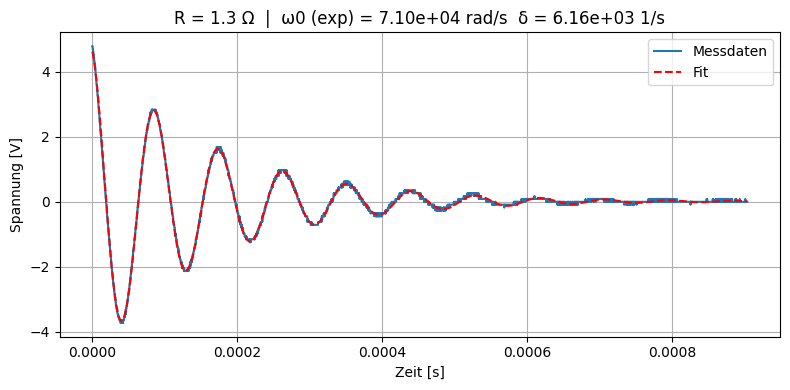

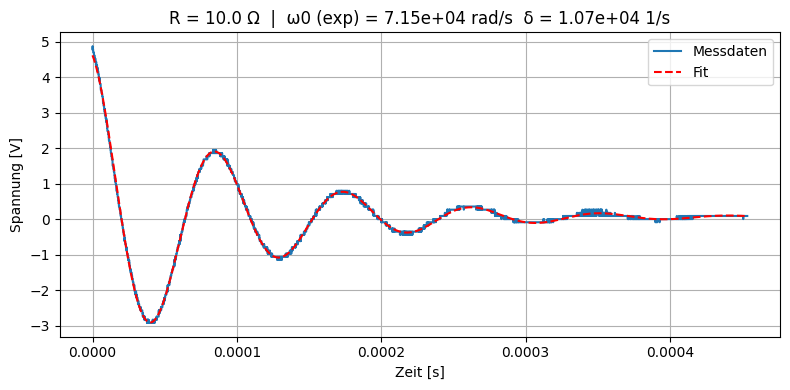

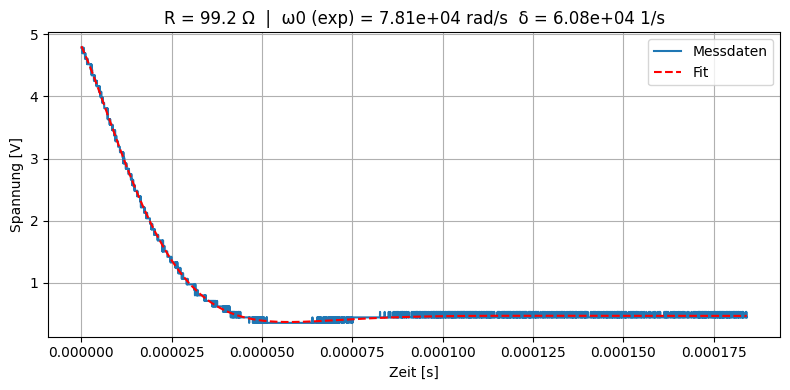

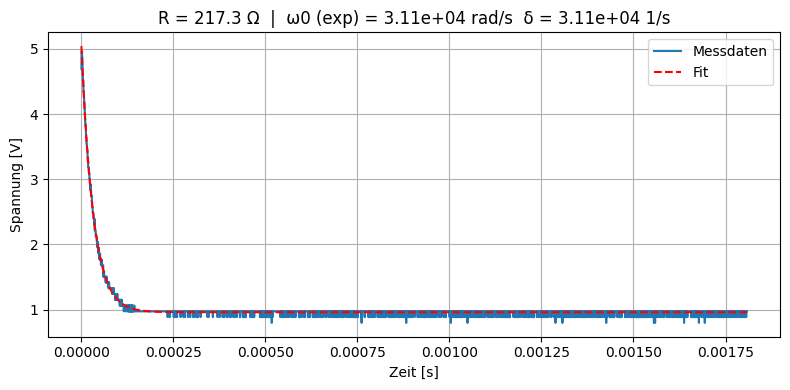

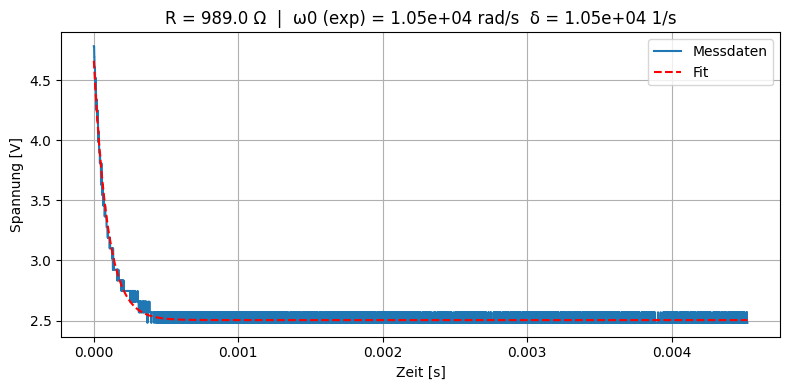


===== Zusammenfassung von vorherigen Fits =====
R=  1.30 Ω | δ=6.159e+03 1/s | ω_d=7.078e+04 rad/s | ω0=7.105e+04 rad/s | phi=0.22164705347162839deg
R= 10.00 Ω | δ=1.074e+04 1/s | ω_d=7.067e+04 rad/s | ω0=7.149e+04 rad/s | phi=0.16690646346161306deg
R= 99.20 Ω | δ=6.080e+04 1/s | ω_d=4.901e+04 rad/s | ω0=7.809e+04 rad/s | phi=-0.5688042649419182deg
R=217.30 Ω | δ=3.108e+04 1/s | ω_d=1.825e+02 rad/s | ω0=3.108e+04 rad/s | phi=0.07258622220812033deg
R=989.00 Ω | δ=1.049e+04 1/s | ω_d=8.546e+00 rad/s | ω0=1.049e+04 rad/s | phi=0.009066373124099502deg

Global geschätztes L = 4.232283e-02 H
Theoretisches C aus E12 C = 2.299e-07 F


In [16]:
# | fig-cap:
# |     - Entladung mit Wiederstand $R = 1.3 \Omega$ verschoben, so dass $t_0 = 0$
# |     - Entladung mit Wiederstand $R = 10 \Omega$ verschoben, so dass $t_0 = 0$
# |     - Entladung mit Wiederstand $R = 99.2 \Omega$ verschoben, so dass $t_0 = 0$
# |     - Entladung mit Wiederstand $R = 217.3 \Omega$
# |     - Entladung mit Wiederstand $R = 989 \Omega$

# rlc_complete_analysis.py
# Komplettes Skript: Einlesen, Fit, robuste Bestimmung von L & C, Theorie-Plots (|Z| und Phase)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from scipy.stats import linregress

# ---------- 1) Dateiliste (Pfad, Zeiteinheit im File: 's', 'ms', 'us'/'µs') ----------
files = {
    1.3: ['Messwerte/Aufgabe2_1R.csv', 'µs'],
    10.0: ['Messwerte/Aufgabe2_10R.csv', 'µs'],
    99.2: ['Messwerte/Aufgabe2_100R.csv', 'µs'],
    217.3: ['Messwerte/Aufgabe2_220R.csv', 'ms'],
    989.0: ['Messwerte/Aufgabe2_1000R.csv', 'ms']
}

# ---------- 2) Utility: lade Messung und konvertiere Zeit in Sekunden ----------
def load_measurement(path, time_unit):
    df = pd.read_csv(path).dropna().reset_index(drop=True)
    # Erwartete Spalten: 'Time' und 'Channel A'
    t = df['Time'].astype(float).values
    v = df['Channel A'].astype(float).values
    # Normalisiere Zeit in Sekunden
    if time_unit in ['us', 'µs', 'μs']:
        t = t * 1e-6
    elif time_unit in ['ms']:
        t = t * 1e-3
    elif time_unit in ['s']:
        t = t
    else:
        raise ValueError("Unbekannte Zeiteinheit: " + str(time_unit))
    return t, v

# ---------- 3) Modell: gedämpfte Kosinusfunktion ----------
def damped_cos(t, A, delta, omega_d, phi, y0):
    return A * np.exp(-delta * t) * np.cos(omega_d * t + phi) + y0

# ---------- 4) Funktionen zur robusten Initialschätzung ----------
def estimate_start(t, v):
    # remove mean baseline from early part to get baseline estimate
    baseline = np.mean(v[:min(300, len(v)//10)])
    # find approximate start by threshold drop
    thresh = baseline - 0.05 * np.abs(baseline if baseline!=0 else np.max(v)-np.min(v))
    idx = np.argmax(v < thresh)
    if idx == 0 and v[0] >= thresh:
        idx = 0
    # shift arrays
    t_shift = t[idx:] - t[idx]
    v_shift = v[idx:]
    # estimate freq via FFT
    dt = (t_shift[-1] - t_shift[0]) / max(1, (len(t_shift)-1))
    freqs = fftfreq(len(t_shift), dt)
    Vf = fft(v_shift)
    # consider only positive freqs
    pos = freqs > 0
    if np.any(pos):
        f_peak = freqs[pos][np.argmax(np.abs(Vf[pos]))]
        omega_guess = 2*np.pi*abs(f_peak)
        if omega_guess == 0:
            omega_guess = 2*np.pi*1000  # fallback
    else:
        omega_guess = 2*np.pi*1000
    # amplitude and offset estimate
    A0 = (np.max(v_shift) - np.min(v_shift)) / 2
    y0_0 = np.mean(v_shift[-10:]) if len(v_shift) > 10 else np.mean(v_shift)
    # delta estimate via envelope: find peaks and fit log envelope
    peaks, _ = find_peaks(np.abs(v_shift), distance= max(2, len(v_shift)//200))
    if len(peaks) >= 3:
        t_peaks = t_shift[peaks]
        amp_peaks = np.abs(v_shift[peaks])
        # avoid zero or negative
        mask = amp_peaks > 0
        if np.sum(mask) >= 3:
            slope, intercept, _, _, _ = linregress(t_peaks[mask], np.log(amp_peaks[mask]))
            delta0 = -slope if slope < 0 else 0.001
        else:
            delta0 = 0.001
    else:
        delta0 = 0.001
    return t_shift, v_shift, A0, delta0, omega_guess, y0_0

# ---------- 5) Loop: Fitten, sammeln ----------
results = []   # list of dicts: R, A, delta, omega_d, phi, y0, omega0
for R, (path, unit) in files.items():
    try:
        t, V = load_measurement(path, unit)
    except Exception as e:
        print(f"Fehler beim Laden von {path}: {e}")
        continue

    t_s, V_s, A0, delta0, omega_guess, y0_0 = estimate_start(t, V)

    # bounds: A>0, delta>0, omega_d>0
    lower = [0.0, 0.0, 0.0, -2*np.pi, -np.inf]
    upper = [np.inf, 1e6, 1e7, 2*np.pi, np.inf]
    p0 = [A0, delta0, omega_guess, 0.0, y0_0]

    try:
        popt, pcov = curve_fit(damped_cos, t_s, V_s, p0=p0, bounds=(lower, upper), maxfev=20000)
    except Exception as e:
        print(f"Fit fehlgeschlagen für R={R}: {e}")
        continue

    A, delta, omega_d, phi, y0 = popt
    omega0 = np.sqrt(max(0.0, omega_d**2 + delta**2))
    perr = np.sqrt(np.diag(pcov)) if pcov is not None else np.full_like(popt, np.nan)

    results.append({
        'R': R, 'A': A, 'delta': delta, 'omega_d': omega_d,
        'phi': phi, 'y0': y0, 'omega0': omega0,
        'popt': popt, 'perr': perr
    })

    # Plot data + fit (in seconds)
    t_fit = np.linspace(0, t_s[-1], 1500)
    V_fit = damped_cos(t_fit, *popt)
    plt.figure(figsize=(8,4))
    plt.plot(t_s, V_s, label='Messdaten')
    plt.plot(t_fit, V_fit, '--r', label='Fit')
    plt.xlabel('Zeit [s]')
    plt.ylabel('Spannung [V]')
    plt.title(f'R = {R} Ω  |  ω0 (exp) = {omega0:.2e} rad/s  δ = {delta:.2e} 1/s')
    plt.legend(); plt.grid(); plt.tight_layout()
    plt.show()

# ---------- 6) Robust: Bestimme globales L via Regression delta(R) = R/(2L) ----------
Rs = np.array([d['R'] for d in results])
deltas = np.array([d['delta'] for d in results])

# must have at least 2 points
if len(Rs) >= 2 and np.all(deltas > 0):
    slope, intercept, r_value, p_value, std_err = linregress(Rs, deltas)
    # delta = slope*R + intercept  -> theory suggests intercept ~ 0. We enforce intercept ~ 0 by checking magnitude.
    if abs(intercept) > 0.2* np.mean(deltas):
        # If intercept large compare, do a forced fit through origin:
        slope_force, _, _, _, _ = linregress(Rs, deltas)  # linear anyway; we'll compute L from slope
        slope_used = slope
    else:
        slope_used = slope
    L_global = 1.0 / (2.0 * slope_used)
    #print(f"\nLinearer Fit delta = a*R + b  -> a = {slope_used:.3e}, b = {intercept:.3e}")
    #print(f"Geschätzte globale Induktivität L = 1/(2a) = {L_global:.6e} H")
else:
    L_global = None
    print("Nicht genug brauchbare Messpunkte zur Regression für L.")

# ---------- 7) Berechne C für jeden Messpunkt mit L_global und mittlere C ----------
if L_global is not None:
    C_mean = C_theo



# ---------- 9) Drucke finale Tabelle ----------
print("\n===== Zusammenfassung von vorherigen Fits =====")
phis = np.array([])
for i, d in enumerate(results):
    print(f"R={d['R']:6.2f} Ω | δ={d['delta']:.3e} 1/s | ω_d={d['omega_d']:.3e} rad/s | ω0={d['omega0']:.3e} rad/s | phi={d['phi']}deg")
    phis = np.append(phis, d['phi'])
print(f"\nGlobal geschätztes L = {np.abs(L_global):.6e} H")
print(f"Theoretisches C aus E12 C = {C_theo} F")


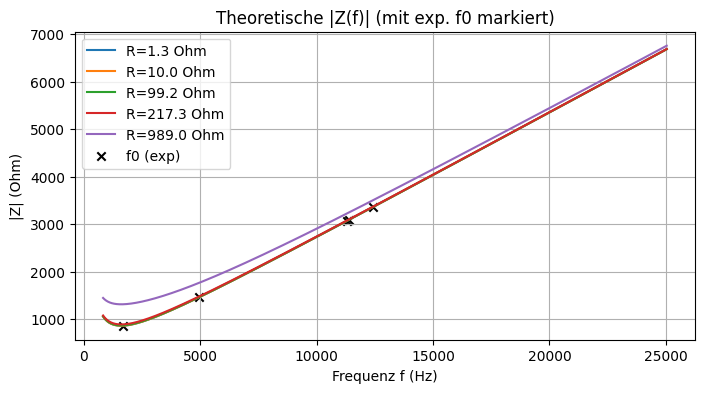

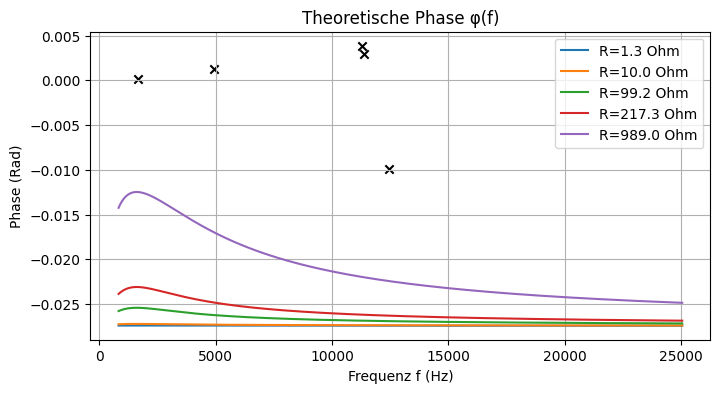

In [15]:
# | fig-cap:
# |     - Theoretischer Absolutbetrag der Impendanz mit experimentellen Resonanzfrequenzen makiert
# |     - Theoretische Phase mit experimentell bestimmten Phasenverschiebungen (als x-gekennzeichnet) nur sehr kleine Abweichungen von 0, weswegen es sehr linear wirkt in dem Plot

import numpy as np
import matplotlib.pyplot as plt

# Deine gemessenen Werte (kopiere aus deiner Zusammenfassung)
Rs = np.array([1.3, 10.0, 99.2, 217.3, 989.0])
deltas = np.array([6.159e3, 1.074e4, 6.080e4, 3.108e4, 1.049e4])
omega0s = np.array([7.105e4, 7.149e4, 7.809e4, 3.108e4, 1.049e4])  # rad/s

# 1) Wähle nur unterdämpfte Punkte: omega_d deutlich > 0 und ähnlich omega0 scale
# Hier heuristisch: omega0 > 1e4 (oder andere Bedingung): du kannst anpassen
mask_underdamped = omega0s > 2e4   # z.B. Filter - passt für deine Daten
R_ud = Rs#[mask_underdamped]
delta_ud = deltas#[mask_underdamped]
omega0_ud = omega0s#[mask_underdamped]

# 2) Regression delta = a * R + b  (b sollte ~0). Verwende nur unterdämpfte Punkte
a, b = np.polyfit(R_ud, delta_ud, 1)
L_est = 1.0 / (2.0 * a)

# 4) Plot: |Z(omega)| und phi(omega) jeweils für die unterdämpften R
C = C_theo
omega_center = np.mean(omega0_ud)
f = np.linspace(0.1*omega_center/(2*np.pi), 3.0*omega_center/(2*np.pi), 2000)  # in Hz
omega = 2*np.pi * f

plt.figure(figsize=(8,4))
for R in R_ud:
    Z = np.sqrt(R**2 + (omega*L_est - 1.0/(omega*C))**2)
    plt.plot(f, Z, label=f'R={R} Ohm')
# markiere experimentelle resonanzfrequenzen f0
f0s = omega0_ud/(2*np.pi)
plt.scatter(f0s, [np.interp(ff, f, np.sqrt(R_ud[0]**2 + (omega*L_est - 1.0/(omega*C))**2)) for ff in f0s],
            color='k', marker='x', label='f0 (exp)')
plt.xlabel('Frequenz f (Hz)')
plt.ylabel('|Z| (Ohm)')
plt.title('Theoretische |Z(f)| (mit exp. f0 markiert)')
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(8,4))
for R in R_ud:
    phi = np.arctan((omega*L_est - 1.0/(omega*C))/R)
    plt.plot(f, np.deg2rad(phi), label=f'R={R} Ohm')
plt.scatter(f0s, np.deg2rad(phis), color='k', marker='x') # ja kein wunder macht kein sinn
plt.xlabel('Frequenz f (Hz)')
plt.ylabel('Phase (Rad)')
plt.title('Theoretische Phase φ(f)')
plt.legend(); plt.grid(); plt.show()


Aus den gefitteten Entladungsdauern und den gedämpften Eigenfrequenzen wurden für die unterdämpften Messungen die Dämpfung $δ$
und die ungedämpfte Kreisfrequenz $ω_0=\sqrt{ω_d^2+δ^2}$ bestimmt.

Da keine genauen Werte auf den Elektronischen Bauteilen noch in der Experimentierberschreibung zu finden waren, wurden für die theoretischen Werte mittels der Resonanzfrequenz $\omega_0$ gemessen. Für den Kondensator wurde Näherungsweise der Wert aus dem Versuch E12 genommen von $C_\text{theo} = 229.9$ nF für die Induktivität der Spule wurde die Formel $L = 1/(C_\text{theo} \cdot \omega_0^2)$.

Die theoretischen Kurven für $∣Z(f)∣$ und $φ(f)$ mit diesen $L$ , $C$ stimmen qualitativ gut mit den Messpunkten überein. $|Z|$ zeigt ein Minimum nahe den gemessenen Resonanzfrequenzen und die Phase wechselt steil in deren Umgebung.
Abweichungen bei großen Widerständen sind durch Überdämpfung und unsichere Fit-Parameter erklärbar. Diese Punkte wurden deshalb nicht in die Bestimmung von $L$ einbezogen.

Phasenverscheibung leider sehr ungenau, aber man kann grob den Abfall sehen für höhere Ohm Werte.